In [28]:
# This cell imports the libraries needed for clustering, evaluation, plotting, similarity search, and saving files.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [52]:
# This cell loads the updated SVD table from the balanced_desc_only dataset.
# This file already contains the SVD semantic vectors.

svd_df = pd.read_csv("../brit/balanced_desc_only_svd_table.csv")

print("SVD table shape:", svd_df.shape)
print("Columns:", svd_df.columns[:10].tolist(), "...")

svd_df.head()

SVD table shape: (10000, 1780)
Columns: ['name', 'description', 'average_score', 'class', 'SV_1', 'SV_2', 'SV_3', 'SV_4', 'SV_5', 'SV_6'] ...


,name,description,average_score,class,SV_1,SV_2,SV_3,SV_4,SV_5,SV_6,...,SV_1767,SV_1768,SV_1769,SV_1770,SV_1771,SV_1772,SV_1773,SV_1774,SV_1775,SV_1776
0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,1,0.313399,-0.241016,-0.208006,0.222448,-0.325501,-0.795861,...,-0.000006,0.000113,0.000067,0.000021,-0.000033,0.000089,0.000058,-0.000143,-0.000013,0.000201
1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,1,0.215025,-0.138837,-0.116791,-0.622929,0.656279,-0.313131,...,-0.000043,0.000014,0.000168,0.000098,-0.000091,-0.000068,-0.000015,0.000147,-0.000098,-0.000124
2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,1,0.313399,-0.241016,-0.208006,0.222448,-0.325501,-0.795861,...,-0.000006,0.000113,0.000067,0.000021,-0.000033,0.000089,0.000058,-0.000143,-0.000013,0.000201
3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,1,0.313399,-0.241016,-0.208006,0.222448,-0.325501,-0.795861,...,-0.000006,0.000113,0.000067,0.000021,-0.000033,0.000089,0.000058,-0.000143,-0.000013,0.000201
4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,1,0.215025,-0.138837,-0.116791,-0.622929,0.656279,-0.313131,...,-0.000043,0.000014,0.000168,0.000098,-0.000091,-0.000068,-0.000015,0.000147,-0.000098,-0.000124


In [53]:
# This cell selects only the SVD feature columns.
# These are the numerical vectors used for clustering.
# We do not use name, description, average_score, or class as clustering inputs.

sv_cols = [col for col in svd_df.columns if col.startswith("SV_")]

X_svd = svd_df[sv_cols].values

print("Number of SVD columns:", len(sv_cols))
print("X_svd shape:", X_svd.shape)

Number of SVD columns: 1776
X_svd shape: (10000, 1776)


In [54]:
# This cell removes duplicate name-description pairs before clustering.
# This helps prevent repeated game entries from dominating the clusters.

svd_unique_df = svd_df.drop_duplicates(subset=["name", "description"]).copy()

sv_cols = [col for col in svd_unique_df.columns if col.startswith("SV_")]
X_svd_unique = svd_unique_df[sv_cols].values

print("Original dataset shape:", svd_df.shape)
print("Deduplicated dataset shape:", svd_unique_df.shape)
print("Unique SVD feature shape:", X_svd_unique.shape)

Original dataset shape: (10000, 1780)
Deduplicated dataset shape: (4689, 1780)
Unique SVD feature shape: (4689, 1776)


In [55]:
# This cell tests different KMeans k values on the deduplicated dataset.
# We compare silhouette score and Davies-Bouldin score for each k.

k_results_unique = []

for k in range(2, 11):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(X_svd_unique)

    sil_temp = silhouette_score(X_svd_unique, labels_temp)
    db_temp = davies_bouldin_score(X_svd_unique, labels_temp)

    k_results_unique.append({
        "k": k,
        "silhouette_score": sil_temp,
        "davies_bouldin_score": db_temp
    })

k_results_unique_df = pd.DataFrame(k_results_unique)

k_results_unique_df

,k,silhouette_score,davies_bouldin_score
0,2,0.005912,6.189134
1,3,0.006034,9.664212
2,4,0.004842,8.754649
3,5,0.006475,7.901160
4,6,0.007369,8.892590
5,7,0.008257,9.021216
6,8,0.007687,8.254327
7,9,0.008140,7.746595
8,10,0.008743,8.208704


In [57]:
# This cell tests different numbers of SVD components for clustering.
# Instead of using all 1776 SVs, we try smaller feature sets.
# This can make clustering cleaner because too many dimensions can make distances noisy.

component_results = []

component_options = [50, 100, 200, 300, 500, 750, 1000]

for n_components in component_options:
    selected_sv_cols = [f"SV_{i}" for i in range(1, n_components + 1)]
    selected_sv_cols = [col for col in selected_sv_cols if col in svd_unique_df.columns]

    X_temp = svd_unique_df[selected_sv_cols].values

    kmeans_temp = KMeans(
        n_clusters=5,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(X_temp)

    sil_temp = silhouette_score(X_temp, labels_temp)
    db_temp = davies_bouldin_score(X_temp, labels_temp)

    component_results.append({
        "n_components": len(selected_sv_cols),
        "k": 5,
        "silhouette_score": sil_temp,
        "davies_bouldin_score": db_temp
    })

component_results_df = pd.DataFrame(component_results)

component_results_df

,n_components,k,silhouette_score,davies_bouldin_score
0,50,5,0.140948,1.849512
1,100,5,0.084474,2.633972
2,200,5,0.045980,3.888346
3,300,5,0.035865,4.344357
4,500,5,0.024004,5.326427
5,750,5,0.016005,6.114369
6,1000,5,0.013021,6.801741


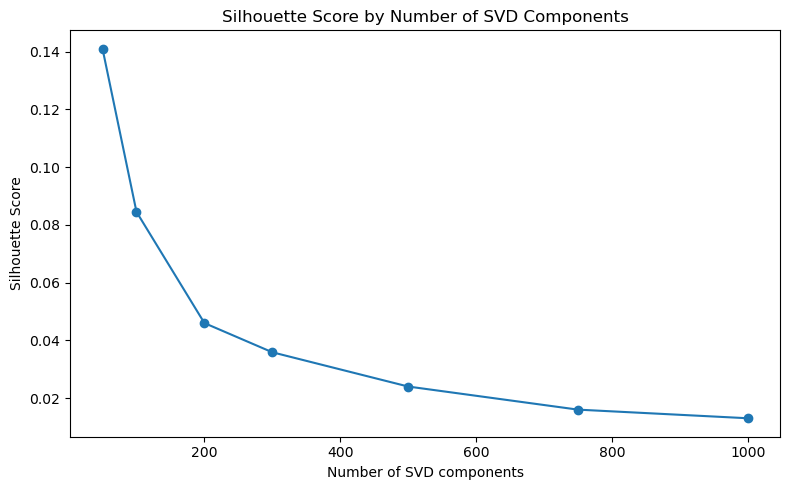

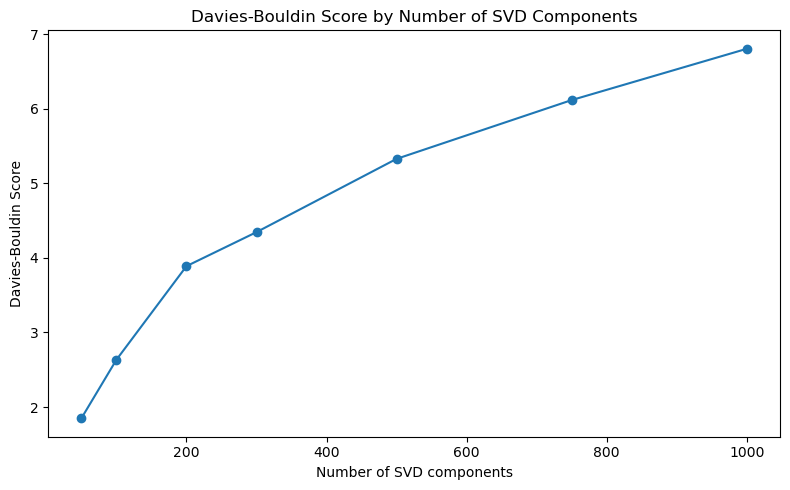

In [58]:
# This cell plots clustering scores for different SVD component counts.

plt.figure(figsize=(8, 5))
plt.plot(component_results_df["n_components"], component_results_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of SVD Components")
plt.xlabel("Number of SVD components")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(component_results_df["n_components"], component_results_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score by Number of SVD Components")
plt.xlabel("Number of SVD components")
plt.ylabel("Davies-Bouldin Score")
plt.tight_layout()
plt.show()

In [60]:
# This cell tests different k values using the best SVD component count.
# Based on the previous experiment, 50 SVD components gave the best clustering scores.

best_n_components = 50

final_sv_cols = [f"SV_{i}" for i in range(1, best_n_components + 1)]
X_svd_unique_50 = svd_unique_df[final_sv_cols].values

k_results_50 = []

for k in range(2, 16):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(X_svd_unique_50)

    sil_temp = silhouette_score(X_svd_unique_50, labels_temp)
    db_temp = davies_bouldin_score(X_svd_unique_50, labels_temp)

    k_results_50.append({
        "k": k,
        "n_components": best_n_components,
        "silhouette_score": sil_temp,
        "davies_bouldin_score": db_temp
    })

k_results_50_df = pd.DataFrame(k_results_50)

k_results_50_df

,k,n_components,silhouette_score,davies_bouldin_score
0,2,50,0.226528,1.586351
1,3,50,0.114995,2.379672
2,4,50,0.137281,2.074265
3,5,50,0.140948,1.849512
4,6,50,0.113475,2.116754
5,7,50,0.112245,2.127181
6,8,50,0.089268,2.216943
7,9,50,0.093798,2.128070
8,10,50,0.097639,2.110035
9,11,50,0.089307,2.217501


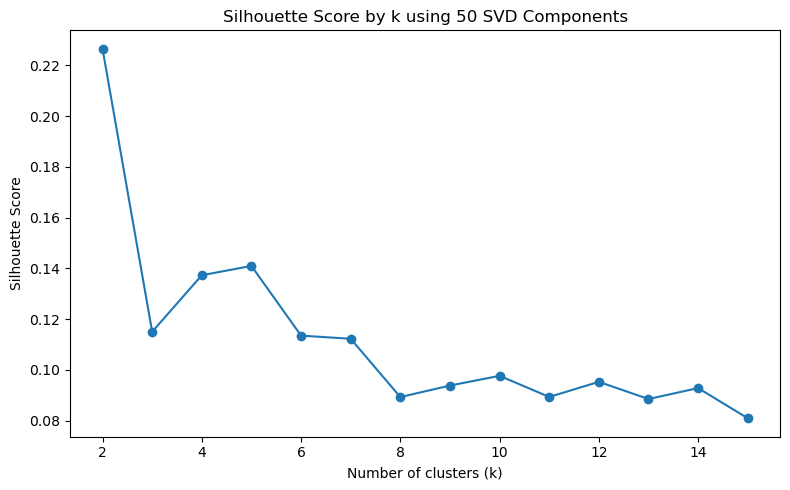

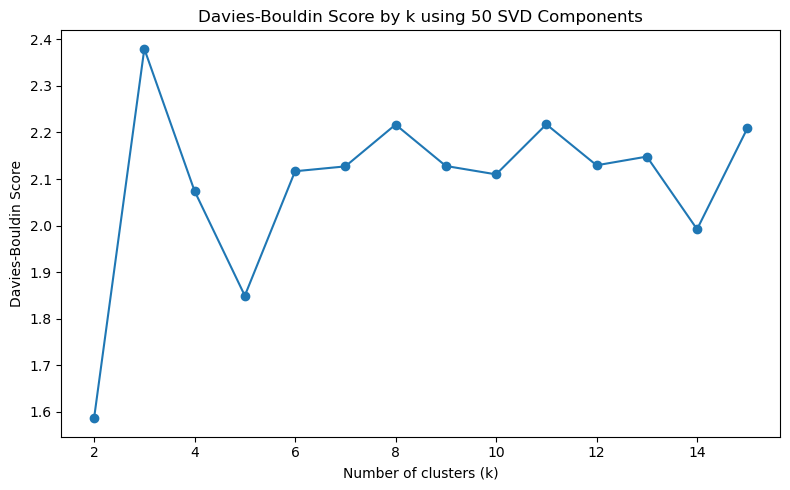

In [61]:
# This cell plots the k evaluation results using 50 SVD components.

plt.figure(figsize=(8, 5))
plt.plot(k_results_50_df["k"], k_results_50_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by k using 50 SVD Components")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_results_50_df["k"], k_results_50_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score by k using 50 SVD Components")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Score")
plt.tight_layout()
plt.show()